In [ ]:
import os

# Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("barkataliarbab/license-plate-detection-dataset-10125-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'license-plate-detection-dataset-10125-images' dataset.
Path to dataset files: /kaggle/input/license-plate-detection-dataset-10125-images


In [ ]:
# Load dataset configuration
dataset_path = path + "/data.yaml"

# Check dataset information
print(open(dataset_path).read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['License_Plate']

roboflow:
  workspace: roboflow-universe-projects
  project: license-plate-recognition-rxg4e
  version: 11
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/11


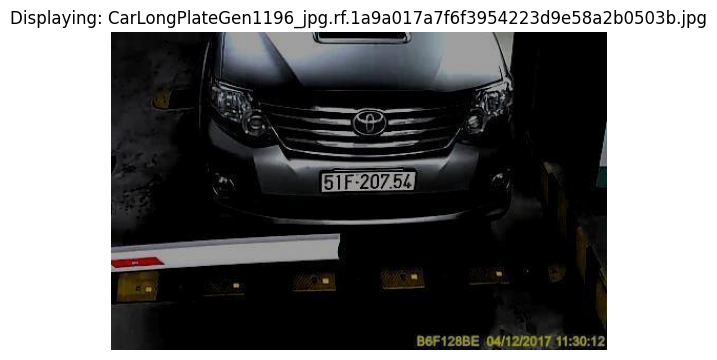

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Construct the path to the training images directory
train_images_path = os.path.join(path, "train", "images")

# Get a list of image files in the directory
image_files = [f for f in os.listdir(train_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    # Select the first image file
    first_image_file = image_files[0]
    image_path = os.path.join(train_images_path, first_image_file)

    # Read the image using OpenCV
    image = cv2.imread(image_path)

    # OpenCV reads images in BGR format, matplotlib expects RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.title(f"Displaying: {first_image_file}")
    plt.axis('off') # Hide axes ticks and labels
    plt.show()
else:
    print(f"No image files found in {train_images_path}")

In [ ]:
# Install Ultralytics library which has Yolo
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:00


# ✅ Define the modle

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
# Load YOLOv8 model (small version)
model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
sample = image_files[0]
print(sample)
print

CarLongPlateGen1196_jpg.rf.1a9a017a7f6f3954223d9e58a2b0503b.jpg
/kaggle/input/license-plate-detection-dataset-10125-images


# Preddict Before train on our dataset


image 1/1 /kaggle/input/license-plate-detection-dataset-10125-images/train/images/pic_078_jpg.rf.d1156de3223672ec4677e4be0d183683.jpg: 480x640 2 cars, 45.6ms
Speed: 1.4ms preprocess, 45.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


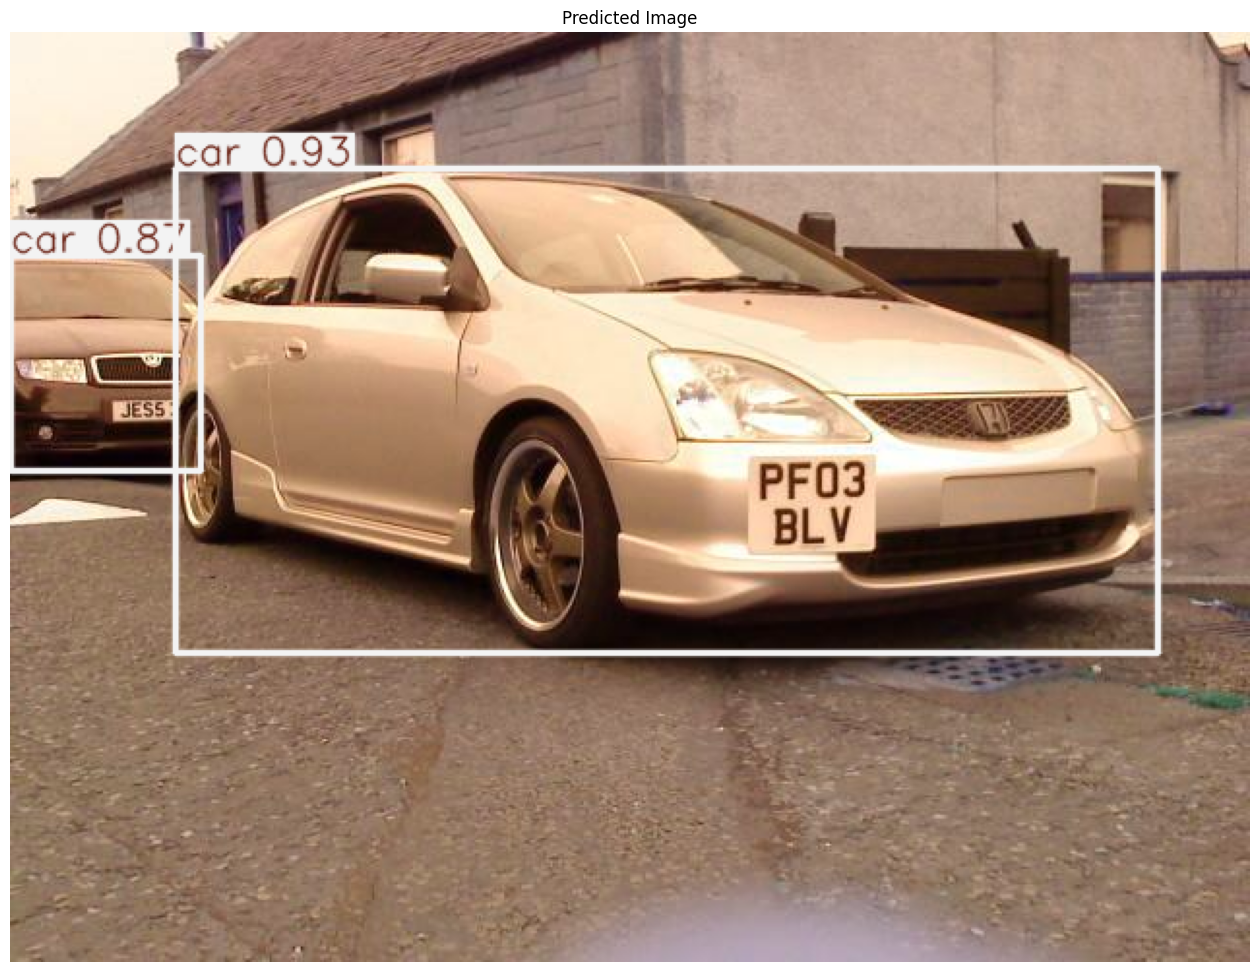

In [ ]:
first_image_file = image_files[10]
image_path = os.path.join(train_images_path, first_image_file)

results = model(image_path, save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()

- : We want to train to predict Plates

# ✅ Train the modle

In [ ]:
model.train(data=dataset_path, epochs=20, imgsz=640) # dataset_path ====> data.yaml (Contains paths lables classes)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/license-plate-detection-dataset-10125-images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

KeyboardInterrupt: 

In [ ]:
metrics = model.val(data=dataset_path)

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 12,867 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 54.4±4.0 MB/s, size: 19.8 KB)
val: Scanning /kaggle/input/license-plate-detection-dataset-10125-images/valid/labels... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 612.9it/s 3.3s
WARNING ⚠️ val: Cache directory /kaggle/input/license-plate-detection-dataset-10125-images/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 5.9it/s 21.8s
                   all       2048       2195      0.981      0.943      0.974      0.684
Speed: 0.7ms preprocess, 6.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val


# Predict after training ( Our dataset )


image 1/1 /kaggle/input/license-plate-detection-dataset-10125-images/train/images/pic_078_jpg.rf.d1156de3223672ec4677e4be0d183683.jpg: 480x640 2 License_Plates, 46.4ms
Speed: 1.2ms preprocess, 46.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict2


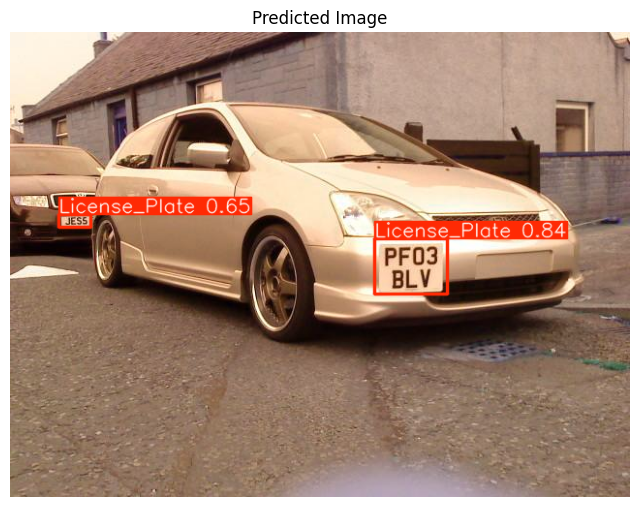

In [ ]:
# Load an image and run inference



first_image_file = image_files[10]
image_path = os.path.join(train_images_path, first_image_file)





model = YOLO(model.trainer.best)  # Use the best weights (after training)
results = model(image_path, save=True) # prediction for unssen image

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(8, 8))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()

# Greateeeee